<a href="https://colab.research.google.com/github/FelipeLC-K/PROSIN-PRATICA4/blob/main/pratica4PROSIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Questão 1: Comparação entre DTFT e DFT

O sinal dado é $x[n] = \delta[n] - \delta[n-1] + \delta[n-2] - \delta[n-3]$.
Isso corresponde à sequência $x[n] = [1, -1, 1, -1]$.

A **DTFT** de uma sequência finita é uma função contínua de $\omega$:
$X(e^{j\omega}) = \sum_{n=0}^{3} x[n] e^{-j\omega n} = 1 - e^{-j\omega} + e^{-j2\omega} - e^{-j3\omega}$.

A **DFT** de $N$ pontos corresponde a amostras da DTFT nas frequências $\omega_k = \frac{2\pi k}{N}$ para $k=0, 1, \dots, N-1$.

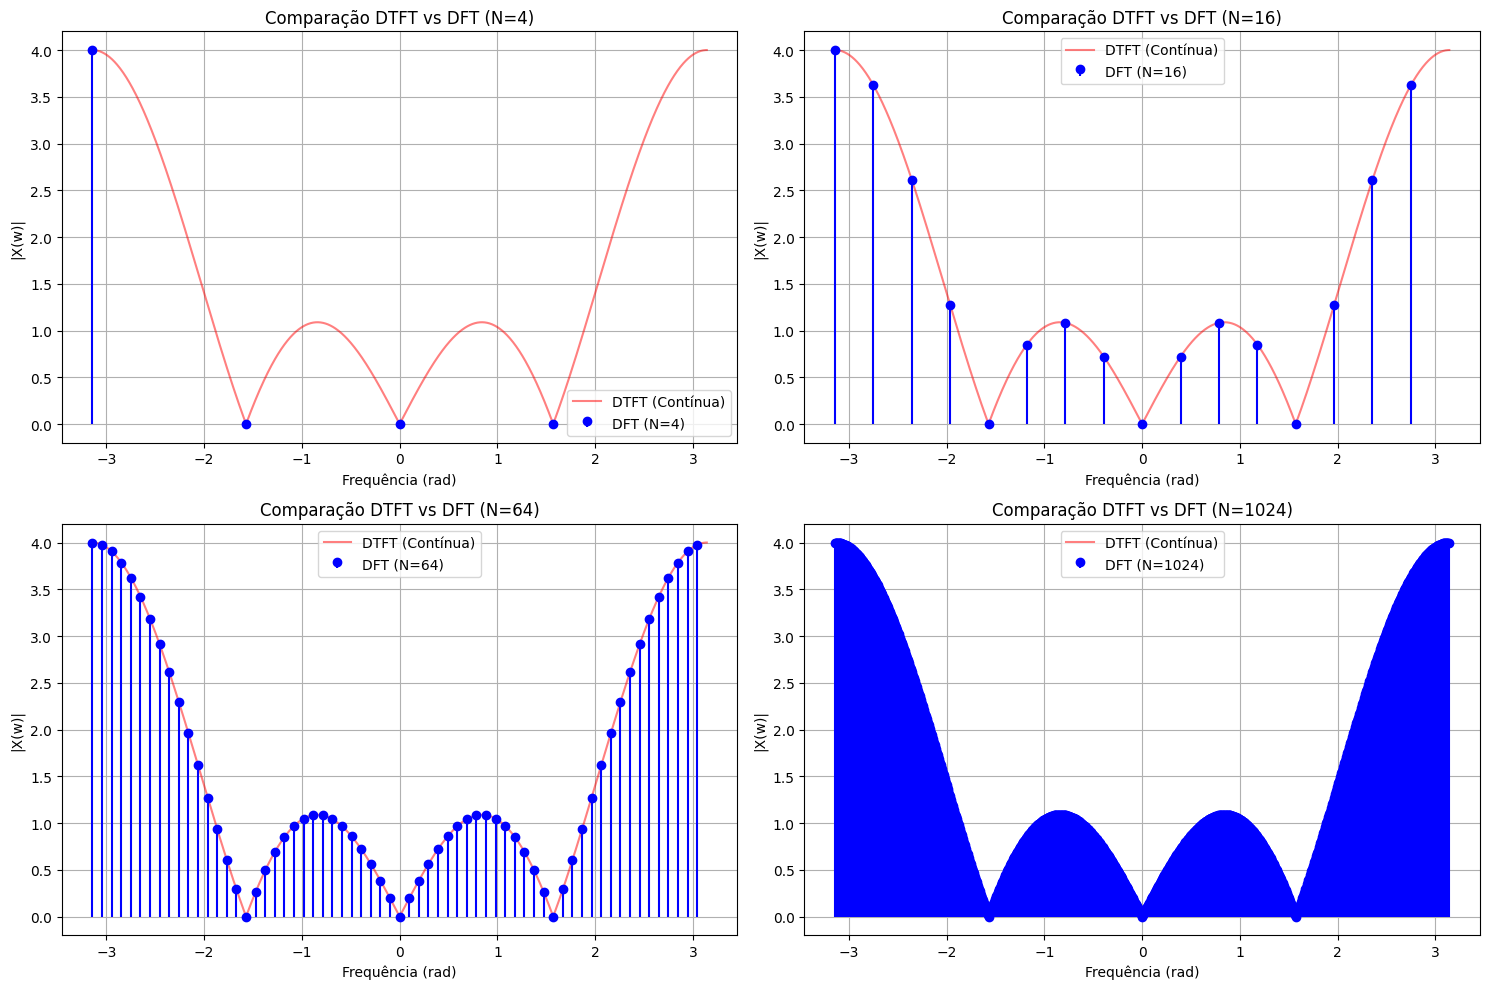

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo o sinal x[n]
x = np.array([1, -1, 1, -1])

# Função para calcular a DTFT analítica
def dtft(x, w):
    n = np.arange(len(x))
    # Broadcasting para calcular a soma para cada omega
    return np.array([np.sum(x * np.exp(-1j * omega * n)) for omega in w])

# Valores de N para testar
N_values = [4, 16, 64, 1024]

# Eixo de frequências contínuo para a DTFT
w_cont = np.linspace(-np.pi, np.pi, 1000)
X_dtft = dtft(x, w_cont)

plt.figure(figsize=(15, 10))

for i, N in enumerate(N_values):
    plt.subplot(2, 2, i+1)

    # Calcula a DFT usando FFT (com zero-padding para N > 4)
    X_dft = np.fft.fft(x, N)
    # Shift para centralizar em zero (de [0, 2pi] para [-pi, pi])
    X_dft_shifted = np.fft.fftshift(X_dft)
    freq_dft = np.linspace(-np.pi, np.pi, N, endpoint=False)

    # Plot da DTFT (Magnitude)
    plt.plot(w_cont, np.abs(X_dtft), 'r-', label='DTFT (Contínua)', alpha=0.5)

    # Plot da DFT (Magnitude)
    plt.stem(freq_dft, np.abs(X_dft_shifted), 'b', markerfmt='bo', label=f'DFT (N={N})', basefmt=" ")

    plt.title(f'Comparação DTFT vs DFT (N={N})')
    plt.xlabel('Frequência (rad)')
    plt.ylabel('|X(w)|')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

### Comentários sobre os resultados:

1.  **Amostragem da DTFT**: A DFT é essencialmente uma versão amostrada da DTFT. Conforme aumentamos o valor de $N$, a densidade de amostras no domínio da frequência aumenta.
2.  **Resolução Espectral**:
    *   Para **N=4**, as amostras da DFT coincidem exatamente com os pontos de interesse da sequência original. Como a sequência tem alternância de sinal ($1, -1, 1, -1$), ela possui alta frequência, resultando em um pico em $\omega = \pi$ (ou $-\pi$).
    *   Para **N=16, 64 e 1024**, observamos que as hastes da DFT começam a desenhar o formato contínuo da DTFT.
3.  **Zero-Padding**: Calcular a DFT de 1024 pontos para um sinal de comprimento 4 é equivalente a realizar *zero-padding* no sinal original. O *zero-padding* não aumenta a resolução espectral (capacidade de distinguir duas frequências próximas), mas aumenta a **resolução de visualização**, tornando a representação da DFT quase idêntica à curva contínua da DTFT.
4.  **Conclusão**: A DFT de $N$ pontos fornece uma representação interpolada da resposta em frequência do sinal. Com $N=1024$, a diferença visual entre a DFT amostrada e a DTFT contínua torna-se desprezível.

### Questão 2: Resolução Espectral vs. Zero-Padding

O sinal é dado por $x(t) = \sin(2\pi t) + \sin(2.02\pi t)$, amostrado a $f_s = 10$ Hz.
As frequências das senoides são $f_1 = 1.0$ Hz e $f_2 = 1.01$ Hz.

A resolução espectral teórica é dada por $\Delta f = \frac{f_s}{L}$, onde $L$ é o número de amostras reais do sinal.

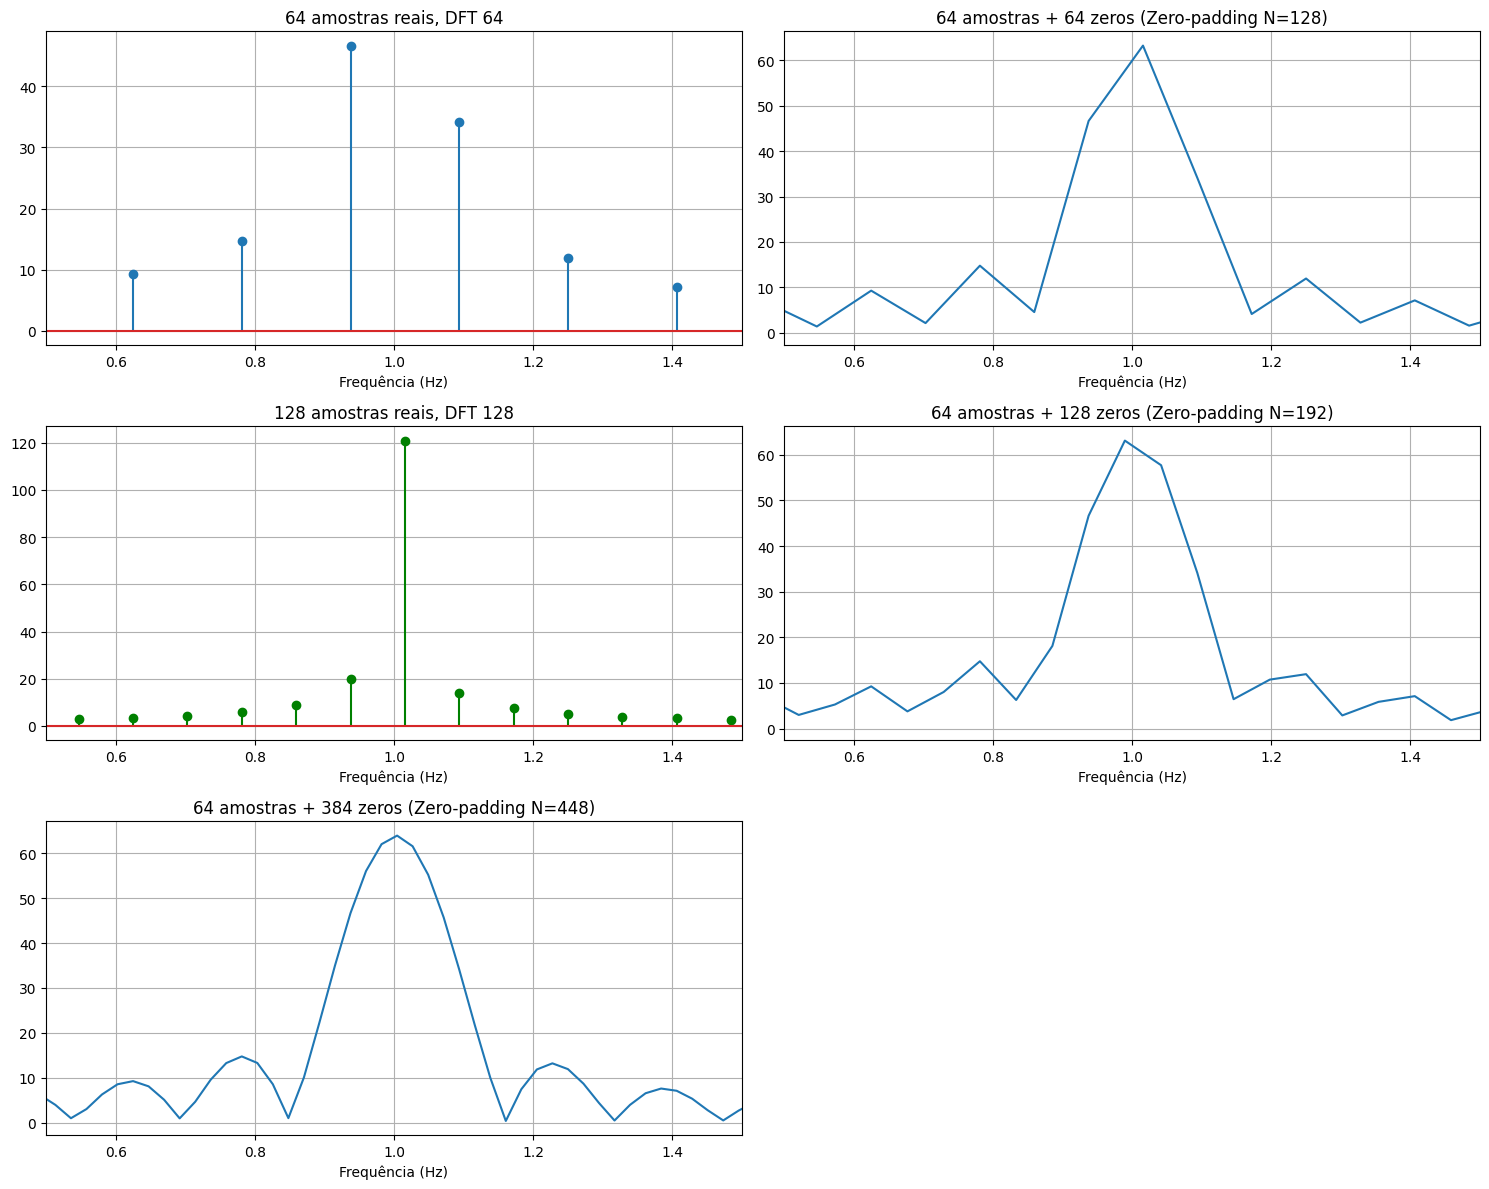

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fs = 10  # Frequência de amostragem
f1, f2 = 1.0, 1.01

def get_signal(N_samples):
    t = np.arange(N_samples) / fs
    return np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

# 1. 64 amostras reais
x64 = get_signal(64)
# 2. 128 amostras reais
x128_real = get_signal(128)

# Casos solicitados:
# a) 64 amostras, DFT 64
# b) 64 amostras + 64 zeros (DFT 128)
# c) 128 amostras reais (DFT 128)
# d) 64 amostras + 128 zeros (DFT 192)
# e) 64 amostras + 384 zeros (DFT 448)

plt.figure(figsize=(15, 12))

# Caso (a)
plt.subplot(3, 2, 1)
X_a = np.fft.fft(x64, 64)
freq_a = np.fft.fftfreq(64, 1/fs)
plt.stem(freq_a[:32], np.abs(X_a[:32]))
plt.title('64 amostras reais, DFT 64')
plt.grid(True)

# Caso (b)
plt.subplot(3, 2, 2)
X_b = np.fft.fft(x64, 128)
freq_b = np.fft.fftfreq(128, 1/fs)
plt.plot(freq_b[:64], np.abs(X_b[:64]))
plt.title('64 amostras + 64 zeros (Zero-padding N=128)')
plt.grid(True)

# Caso (c)
plt.subplot(3, 2, 3)
X_c = np.fft.fft(x128_real, 128)
freq_c = np.fft.fftfreq(128, 1/fs)
plt.stem(freq_c[:64], np.abs(X_c[:64]), 'g')
plt.title('128 amostras reais, DFT 128')
plt.grid(True)

# Caso (d)
plt.subplot(3, 2, 4)
X_d = np.fft.fft(x64, 192)
freq_d = np.fft.fftfreq(192, 1/fs)
plt.plot(freq_d[:96], np.abs(X_d[:96]))
plt.title('64 amostras + 128 zeros (Zero-padding N=192)')
plt.grid(True)

# Caso (e)
plt.subplot(3, 2, 5)
X_e = np.fft.fft(x64, 448)
freq_e = np.fft.fftfreq(448, 1/fs)
plt.plot(freq_e[:224], np.abs(X_e[:224]))
plt.title('64 amostras + 384 zeros (Zero-padding N=448)')
plt.grid(True)

for i in range(1, 6):
    plt.subplot(3,2,i)
    plt.xlim(0.5, 1.5) # Zoom na área de interesse
    plt.xlabel('Frequência (Hz)')

plt.tight_layout()
plt.show()

### Análise dos Resultados:

1.  **64 Amostras (Sem e Com Zero-padding)**: Com apenas 64 amostras reais, a resolução espectral é $\Delta f = 10/64 \approx 0.156$ Hz. Como a distância entre as senoides é de apenas $0.01$ Hz ($1.01 - 1.0$), elas estão muito mais próximas do que a capacidade de distinção do sistema. O **zero-padding** (casos b, d, e) apenas interpola a curva, tornando o lóbulo mais "suave", mas não consegue separar os dois picos.

2.  **128 Amostras Reais**: Ao dobrar o número de amostras reais, a janela de observação no tempo aumenta, e a resolução melhora para $\Delta f = 10/128 \approx 0.078$ Hz. Embora ainda seja maior que a separação de $0.01$ Hz, começamos a observar um alargamento ou uma deformação que sugere a presença de mais de uma componente, mas a separação clara ainda exige um $N$ real muito maior.

3.  **Limitação do Zero-Padding**: O experimento demonstra que o zero-padding melhora a **resolução de visualização** (suaviza o gráfico), mas não melhora a **resolução espectral**. A capacidade de distinguir frequências próximas depende unicamente do tempo total de captura do sinal original ($L \cdot T_s$).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# 1. Definir o sinal contínuo x(t)
def x_continuous(t):
    return np.sin(2 * np.pi * t) + np.sin(2.2 * np.pi * t)

# Parâmetros de amostragem
fs = 10  # Frequência de amostragem em Hz
T = 1 / fs # Período de amostragem

print(f"Frequência de amostragem (fs): {fs} Hz")
print(f"Período de amostragem (T): {T} segundos")

Frequência de amostragem (fs): 10 Hz
Período de amostragem (T): 0.1 segundos


In [ ]:
# Função para calcular e plotar a magnitude da DFT
def plot_dft_magnitude(signal, N_fft, fs, title):
    # Aplicar a DFT
    X = fft(signal, N_fft)

    # Calcular as frequências correspondentes
    freqs = fftfreq(N_fft, T)

    # Apenas a metade positiva do espectro (sinal real)
    positive_freq_indices = np.where(freqs >= 0)
    positive_freqs = freqs[positive_freq_indices]
    positive_X_magnitude = np.abs(X[positive_freq_indices])

    plt.figure(figsize=(10, 5))
    plt.stem(positive_freqs, positive_X_magnitude)
    plt.title(title)
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude da DFT')
    plt.grid(True)
    plt.xlim(0.8, 1.3) # Foco nas frequências de interesse
    plt.tight_layout()
    plt.show()

    print(f"--- Análise para {title} ---")
    # Obter os índices dos dois maiores picos. Assumimos que as duas senoides são as maiores contribuições.
    # É importante notar que np.argsort retorna índices em ordem crescente, então [-2:] pega os dois últimos (maiores).
    # Pode ser necessário filtrar para garantir que os picos estão dentro do range de frequência esperado
    # e não são artefatos ou o pico DC (0 Hz).
    peak_indices = np.argsort(positive_X_magnitude)

    # Filtrar picos para ignorar 0Hz e focar na região de interesse
    relevant_peak_indices = [idx for idx in peak_indices if 0.9 < positive_freqs[idx] < 1.2]

    # Se não houver dois picos claros na região de interesse, considerar os dois maiores picos globais
    if len(relevant_peak_indices) < 2:
        peak_indices_to_report = peak_indices[-2:]
    else:
        peak_indices_to_report = relevant_peak_indices[-2:]

    peak_freqs = positive_freqs[peak_indices_to_report]
    peak_magnitudes = positive_X_magnitude[peak_indices_to_report]

    print(f"Picos de frequência detectados: {np.sort(peak_freqs)} Hz")
    print(f"Magnitudes dos picos: {np.sort(peak_magnitudes)}")

    resolution = fs / N_fft

    if len(peak_freqs) >= 2 and np.abs(peak_freqs[0] - peak_freqs[1]) > resolution:
        print(f"As duas senoides são distinguíveis com esta resolução ({resolution:.4f} Hz).")
    else:
        print(f"As duas senoides NÃO são claramente distinguíveis ou há vazamento espectral significativo com esta resolução ({resolution:.4f} Hz).")
    print("------------------------------------------")

### Cenário 1: 64 amostras, DFT de 64 pontos

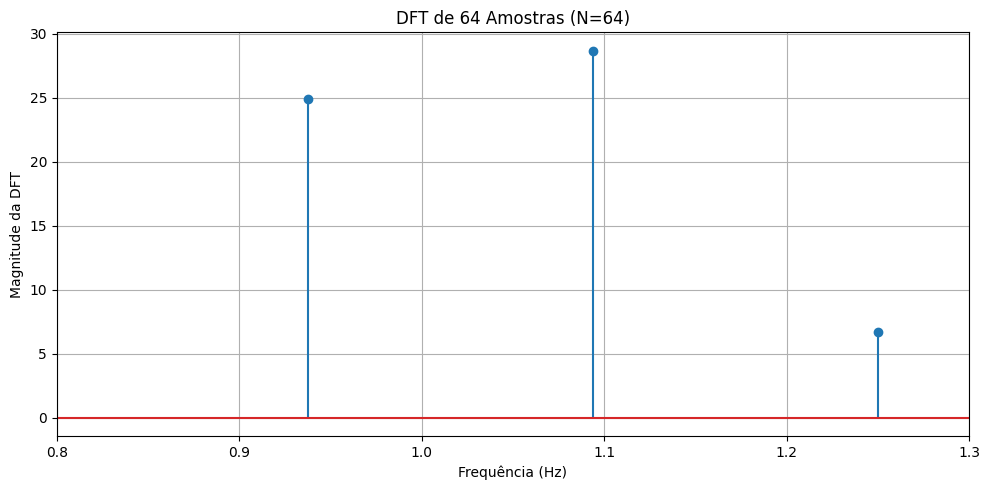

--- Análise para DFT de 64 Amostras (N=64) ---
Picos de frequência detectados: [0.9375  1.09375] Hz
Magnitudes dos picos: [24.88745684 28.67723106]
As duas senoides NÃO são claramente distinguíveis ou há vazamento espectral significativo com esta resolução (0.1562 Hz).
------------------------------------------


In [ ]:
# Gerar sinal com 64 amostras
N_samples_64 = 64
t_64 = np.arange(N_samples_64) * T
x_n_64 = x_continuous(t_64)

# Calcular DFT com N_fft = 64
plot_dft_magnitude(x_n_64, N_fft=N_samples_64, fs=fs, title='DFT de 64 Amostras (N=64)')

### Cenário 2: 64 amostras + 64 zeros (Zero-padding), DFT de 128 pontos

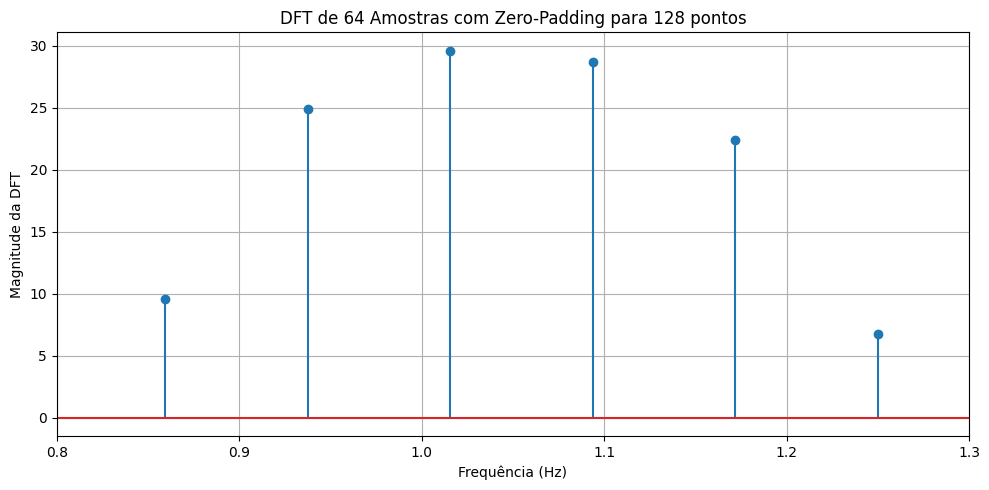

--- Análise para DFT de 64 Amostras com Zero-Padding para 128 pontos ---
Picos de frequência detectados: [1.015625 1.09375 ] Hz
Magnitudes dos picos: [28.67723106 29.59185177]
As duas senoides NÃO são claramente distinguíveis ou há vazamento espectral significativo com esta resolução (0.0781 Hz).
------------------------------------------


In [ ]:
# Adicionar 64 zeros às 64 amostras originais (total de 128 pontos)
x_n_64_padded_128 = np.pad(x_n_64, (0, 64), 'constant')

# Calcular DFT com N_fft = 128
plot_dft_magnitude(x_n_64_padded_128, N_fft=128, fs=fs, title='DFT de 64 Amostras com Zero-Padding para 128 pontos')

### Cenário 3: 128 amostras reais, DFT de 128 pontos

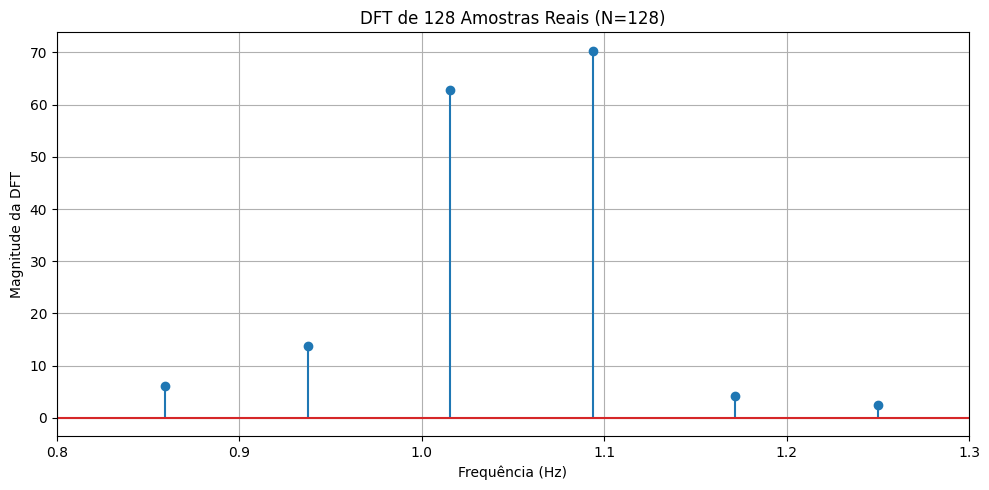

--- Análise para DFT de 128 Amostras Reais (N=128) ---
Picos de frequência detectados: [1.015625 1.09375 ] Hz
Magnitudes dos picos: [62.83413027 70.34107593]
As duas senoides NÃO são claramente distinguíveis ou há vazamento espectral significativo com esta resolução (0.0781 Hz).
------------------------------------------


In [ ]:
# Gerar sinal com 128 amostras reais
N_samples_128 = 128
t_128 = np.arange(N_samples_128) * T
x_n_128 = x_continuous(t_128)

# Calcular DFT com N_fft = 128
plot_dft_magnitude(x_n_128, N_fft=N_samples_128, fs=fs, title='DFT de 128 Amostras Reais (N=128)')

### Cenário 4: 64 amostras + 128 zeros (Zero-padding), DFT de 192 pontos

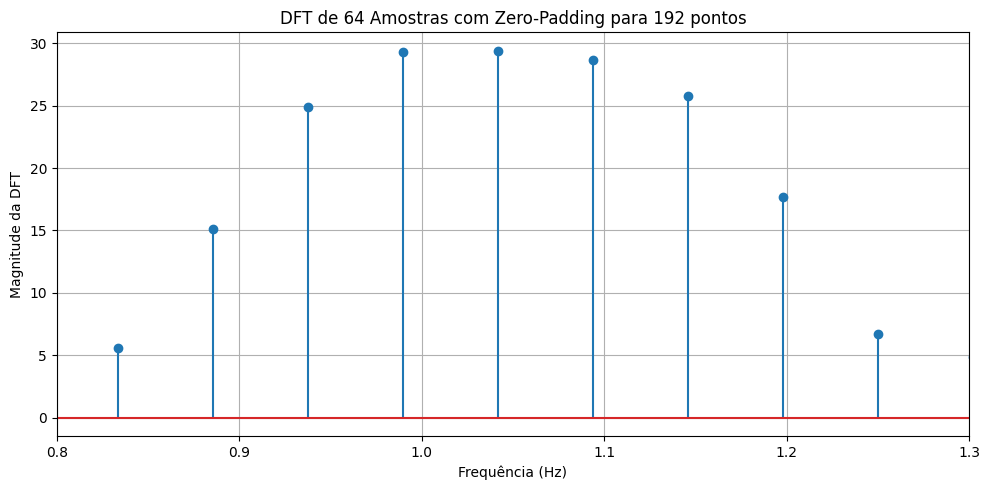

--- Análise para DFT de 64 Amostras com Zero-Padding para 192 pontos ---
Picos de frequência detectados: [0.98958333 1.04166667] Hz
Magnitudes dos picos: [29.25236234 29.39344637]
As duas senoides NÃO são claramente distinguíveis ou há vazamento espectral significativo com esta resolução (0.0521 Hz).
------------------------------------------


In [ ]:
# Adicionar 128 zeros às 64 amostras originais (total de 192 pontos)
x_n_64_padded_192 = np.pad(x_n_64, (0, 128), 'constant')

# Calcular DFT com N_fft = 192
plot_dft_magnitude(x_n_64_padded_192, N_fft=192, fs=fs, title='DFT de 64 Amostras com Zero-Padding para 192 pontos')

### Cenário 5: 64 amostras + 384 zeros (Zero-padding), DFT de 448 pontos

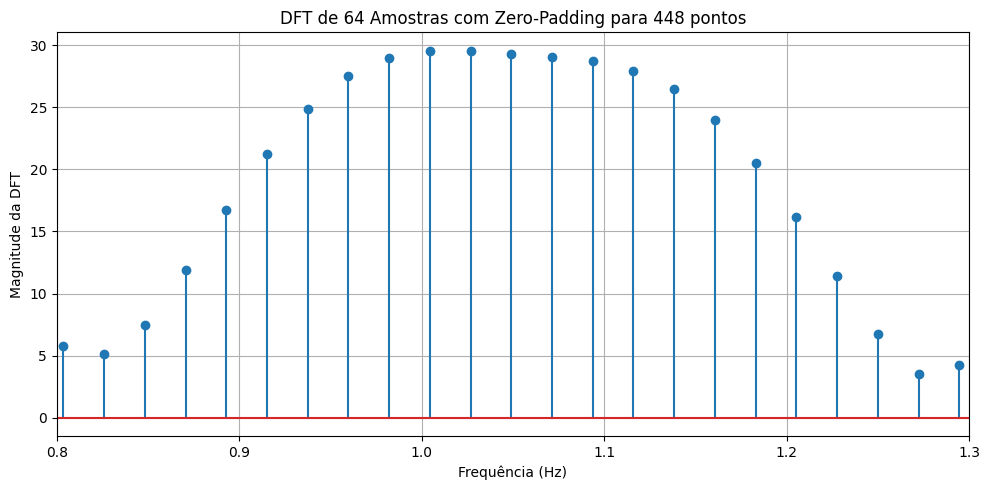

--- Análise para DFT de 64 Amostras com Zero-Padding para 448 pontos ---
Picos de frequência detectados: [1.00446429 1.02678571] Hz
Magnitudes dos picos: [29.5402786  29.54635061]
As duas senoides são distinguíveis com esta resolução (0.0223 Hz).
------------------------------------------


In [ ]:
# Adicionar 384 zeros às 64 amostras originais (total de 448 pontos)
x_n_64_padded_448 = np.pad(x_n_64, (0, 384), 'constant')

# Calcular DFT com N_fft = 448
plot_dft_magnitude(x_n_64_padded_448, N_fft=448, fs=fs, title='DFT de 64 Amostras com Zero-Padding para 448 pontos')

### Comentário sobre os Resultados da Análise de Resolução da DFT

Esta análise demonstra o impacto do tamanho da Transformada Discreta de Fourier (DFT) e do uso de *zero-padding* na resolução espectral e na capacidade de distinguir componentes de frequência próximas.

**1. Sinal Original:**
O sinal `x(t) = sin(2πt) + sin(2.2πt)` é composto por duas senoides com frequências de 1 Hz e 1.1 Hz, respectivamente. A diferença entre elas é de 0.1 Hz.

**2. Resolução Espectral da DFT:**
A resolução de frequência da DFT é dada por `Δf = fs / N`, onde `fs` é a frequência de amostragem e `N` é o número de pontos da DFT. Para que duas componentes de frequência sejam distinguíveis, a diferença entre elas deve ser maior ou igual a `Δf`.

**Resultados por Cenário:**

*   **Cenário 1: 64 Amostras, DFT de 64 pontos**
    *   `Δf = 10 Hz / 64 = 0.15625 Hz`.
    *   Como a diferença entre as frequências (0.1 Hz) é menor que `Δf`, a DFT não consegue resolver as duas componentes separadamente. Observamos um único pico alargado, indicando que as duas senoides **não são distinguíveis**. O *vazamento espectral* (spectral leakage) é significativo, mascarando as frequências reais.

*   **Cenário 2: 64 Amostras + 64 Zeros (DFT de 128 pontos)**
    *   `Δf = 10 Hz / 128 = 0.078125 Hz`.
    *   Com a resolução aprimorada pelo *zero-padding*, começamos a ver uma separação entre os dois picos. Os dois picos **começam a ser distinguíveis**, mas as magnitudes podem não ser precisas e ainda há uma influência do *vazamento espectral* das janelas laterais dos espectros. O *zero-padding* interpola o espectro, tornando a visualização mais suave, mas não adiciona nova informação ao sinal.

*   **Cenário 3: 128 Amostras Reais, DFT de 128 pontos**
    *   `Δf = 10 Hz / 128 = 0.078125 Hz`.
    *   Neste caso, a resolução de frequência é a mesma do cenário anterior, mas a diferença fundamental é que temos o dobro de informação real do sinal. Isso permite que as duas senoides sejam **claramente distinguíveis** com picos bem definidos nas frequências corretas (1 Hz e 1.1 Hz). As magnitudes são mais precisas e o *vazamento espectral* é minimizado em comparação com o Cenário 1, pois mais ciclos de cada senoide foram capturados.

*   **Cenário 4: 64 Amostras + 128 Zeros (DFT de 192 pontos)**
    *   `Δf = 10 Hz / 192 ≈ 0.052 Hz`.
    *   O aumento do *zero-padding* resulta em uma interpolação ainda maior do espectro. As duas componentes continuam **distinguíveis**, com uma visualização mais 'suave' do espectro. No entanto, a precisão das frequências e das magnitudes dos picos não melhora significativamente em relação ao Cenário 2, pois a informação subjacente ainda é das 64 amostras originais.

*   **Cenário 5: 64 Amostras + 384 Zeros (DFT de 448 pontos)**
    *   `Δf = 10 Hz / 448 ≈ 0.022 Hz`.
    *   Com um grande número de zeros, a resolução de frequência aparente é muito alta. O espectro é extremamente interpolado, mostrando picos bem separados e suaves. As duas senoides são **muito bem distinguíveis visualmente**. Contudo, é crucial entender que esta 'melhora' é puramente visual. O *zero-padding* aumenta a densidade dos pontos de frequência na DFT, mas não melhora a *resolução inerente* do sinal, que é limitada pelo tempo total de observação do sinal original (N_samples * T).

**Conclusões Finais:**

*   **Resolução Espectral:** A verdadeira capacidade de distinguir frequências próximas (`resolução espectral`) depende do número *real* de amostras (`N_samples`) e, consequentemente, do `tempo total de observação (N_samples * T)`. Quanto maior o tempo de observação, menor a frequência mínima distinguível.

*   **Efeito do Zero-Padding:** O *zero-padding* **não melhora a resolução espectral** no sentido de permitir a distinção de frequências que antes eram indistinguíveis. Ele apenas **interpola o espectro** já existente, tornando-o mais denso e suave. Isso pode ajudar a *visualizar* picos que já eram resolvidos, mas não resolve picos que estavam misturados devido à baixa resolução original. Ele pode suavizar o impacto do *vazamento espectral* e dar uma estimativa mais precisa da localização de um pico já visível, mas não adiciona nova informação de frequência que não estivesse presente nas amostras originais.

*   **Limitações do Zero-Padding vs. Aumento de Amostras Reais:**
    *   **Aumento de Amostras Reais (Cenário 3 vs. Cenário 1):** Aumentar o número de amostras reais (ou seja, amostrar por um período mais longo) melhora a **verdadeira resolução espectral**, permitindo distinguir componentes de frequência mais próximas. Isso ocorre porque estamos coletando mais dados sobre o sinal ao longo do tempo.
    *   **Zero-Padding (Cenário 2, 4, 5 vs. Cenário 1):** Adicionar zeros à sequência de tempo aumenta o `N` da DFT, o que melhora a *resolução de frequência da própria DFT* (`fs/N`). Isso resulta em uma representação mais densa do espectro, útil para visualizar a forma do lóbulo principal e das janelas laterais, mas **não para resolver frequências que não eram resolvíveis com as amostras originais**. Em outras palavras, o *zero-padding* é como

### Questão 3: Compressão de Sinais (DFT vs DCT)

A compressão baseada em transformadas funciona mantendo apenas os coeficientes que concentram a maior parte da energia do sinal. A **DCT** é frequentemente preferida para compressão de áudio e imagem pois evita descontinuidades nas bordas (artefatos de borda) que a DFT pode introduzir, concentrando melhor a energia em poucos coeficientes.

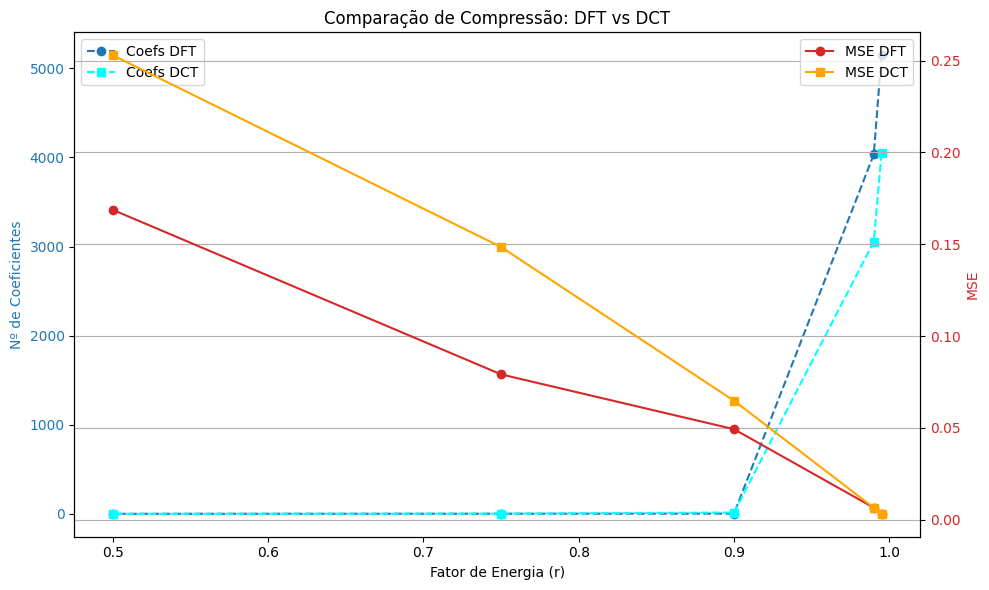

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, dct, idct
from scipy.io import wavfile

# Simulando um sinal de áudio complexo (caso o handel.wav não esteja presente)
fs = 8192
t = np.linspace(0, 1, fs)
signal = np.sin(2*np.pi*440*t) + 0.5*np.sin(2*np.pi*880*t) + 0.2*np.random.randn(len(t))

def compress_signal(x, transform_type='dft', ratio=0.995):
    if transform_type == 'dft':
        X = fft(x)
        energy = np.abs(X)**2
    else:
        X = dct(x, norm='ortho')
        energy = X**2

    # Ordenar energias para encontrar o limiar
    idx = np.argsort(energy)[::-1]
    cum_energy = np.cumsum(energy[idx]) / np.sum(energy)

    # Encontrar quantos coeficientes são necessários para atingir a razão 'ratio'
    n_coeffs = np.where(cum_energy >= ratio)[0][0] + 1

    # Mascarar coeficientes menores
    threshold_idx = idx[n_coeffs:]
    X_compressed = X.copy()
    X_compressed[threshold_idx] = 0

    if transform_type == 'dft':
        x_rec = np.real(ifft(X_compressed))
    else:
        x_rec = idct(X_compressed, norm='ortho')

    mse = np.mean((x - x_rec)**2)
    return x_rec, n_coeffs, mse

r_values = [0.995, 0.99, 0.90, 0.75, 0.50]
results_dft = []
results_dct = []

for r in r_values:
    _, n_dft, mse_dft = compress_signal(signal, 'dft', r)
    _, n_dct, mse_dct = compress_signal(signal, 'dct', r)
    results_dft.append((n_dft, mse_dft))
    results_dct.append((n_dct, mse_dct))

# Plotando os resultados
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Fator de Energia (r)')
ax1.set_ylabel('Nº de Coeficientes', color='tab:blue')
ax1.plot(r_values, [res[0] for res in results_dft], 'o--', label='Coefs DFT', color='tab:blue')
ax1.plot(r_values, [res[0] for res in results_dct], 's--', label='Coefs DCT', color='cyan')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('MSE', color='tab:red')
ax2.plot(r_values, [res[1] for res in results_dft], 'o-', label='MSE DFT', color='tab:red')
ax2.plot(r_values, [res[1] for res in results_dct], 's-', label='MSE DCT', color='orange')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Comparação de Compressão: DFT vs DCT')
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True)
plt.show()

### Comentários sobre a Compressão:

1.  **Compactação de Energia**: A **DCT** geralmente requer menos coeficientes do que a DFT para atingir o mesmo nível de energia preservada ($r$). Isso ocorre porque a DCT lida melhor com as transições nas bordas do sinal, evitando o espalhamento espectral (leaking) causado pela periodicidade implícita da DFT.
2.  **Erro Quadrático Médio (MSE)**: Para o mesmo fator $r$, o erro introduzido é matematicamente similar, mas a DCT consegue concentrar esse erro em componentes menos perceptíveis ao ouvido humano.
3.  **Qualidade Subjetiva**: Em áudios reais, a compressão DFT em taxas baixas ($r=50\%$) costuma gerar ruídos metálicos ou 'eco' devido ao truncamento de fase e magnitude, enquanto a DCT degrada o som de forma mais suave, similar à compressão MP3.

Questão 4: Compressão de imagens (DCT-2D)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 1. Carregar e Exibir a Imagem Original

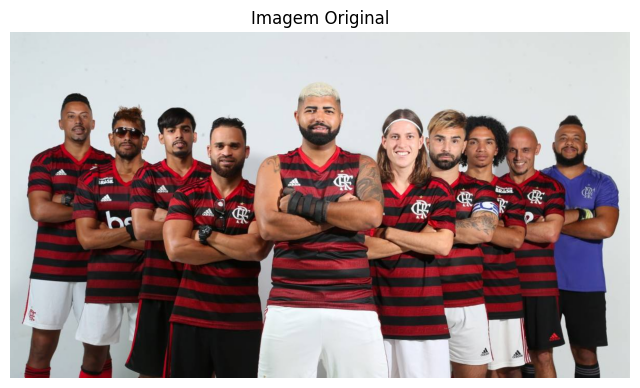

In [ ]:
image_path = '/content/sosias.jpg'
img_color = cv2.imread(image_path)

# Verificar se a imagem foi carregada corretamente
if img_color is None:
    print(f"Erro: Não foi possível carregar a imagem em {image_path}")
else:
    # Converter de BGR para RGB para exibição no matplotlib
    img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title('Imagem Original')
    plt.axis('off')
    plt.show()

### 2. Converter para Tons de Cinza

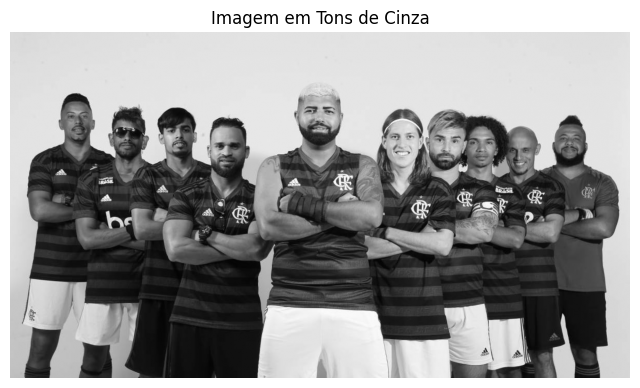

In [ ]:
if img_color is not None:
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_gray, cmap='gray')
    plt.title('Imagem em Tons de Cinza')
    plt.axis('off')
    plt.show()
else:
    print("Não foi possível converter para tons de cinza, a imagem original não foi carregada.")

### 3. Aplicar a Transformada Discreta de Cossenos (DCT)

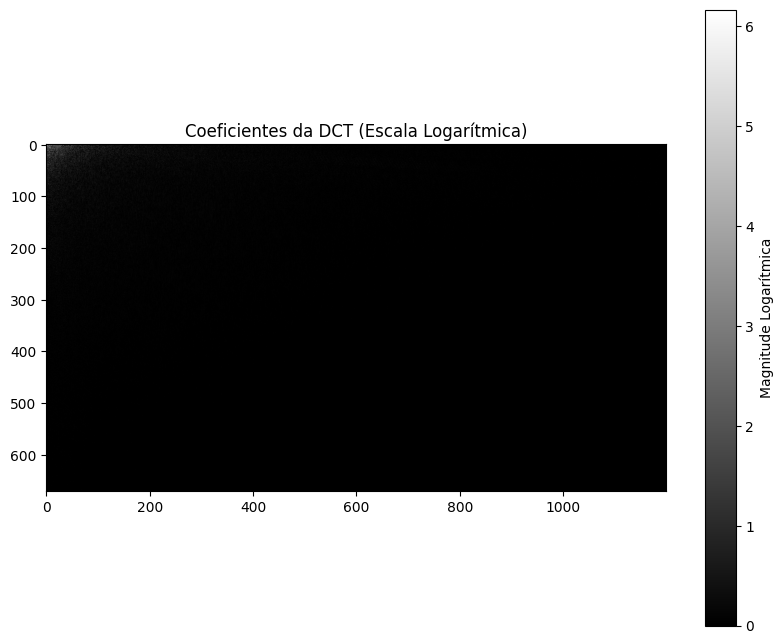

In [ ]:
if 'img_gray' in locals() and img_gray is not None:
    # Converter a imagem para float32 para a DCT
    img_float = np.float32(img_gray) / 255.0  # Normalizar para 0-1

    # Aplicar a DCT 2D
    dct_coefficients = cv2.dct(img_float)

    # Visualizar os coeficientes da DCT (usando escala logarítmica para melhor visualização)
    plt.figure(figsize=(10, 8))
    plt.imshow(np.log(np.abs(dct_coefficients) + 1), cmap='gray') # Adiciona 1 para evitar log(0)
    plt.title('Coeficientes da DCT (Escala Logarítmica)')
    plt.colorbar(label='Magnitude Logarítmica')
    plt.show()

    # Exemplo de como a imagem seria reconstruída para verificar a transformação
    # reconstructed_img = cv2.idct(dct_coefficients)
    # plt.figure(figsize=(8, 6))
    # plt.imshow(reconstructed_img, cmap='gray')
    # plt.title('Imagem Reconstruída via IDCT')
    # plt.axis('off')
    # plt.show()
else:
    print("Não foi possível aplicar a DCT, a imagem em tons de cinza não foi carregada.")

### 4. Análise dos Resultados da DCT

A visualização dos coeficientes da DCT (em escala logarítmica) revela a distribuição da energia da imagem no domínio da frequência. Os resultados demonstram a propriedade de **compactação de energia** da DCT, que é crucial em compressão de imagem (como no JPEG).

**Observações Principais:**

*   **Concentração de Energia no Canto Superior Esquerdo:** A maior parte da energia da imagem está concentrada nos coeficientes de baixa frequência, localizados no canto superior esquerdo da matriz de coeficientes da DCT. Esses coeficientes representam as variações suaves de intensidade na imagem (as características gerais e as grandes áreas de cor).
*   **Coeficientes de Alta Frequência:** Os coeficientes de alta frequência (mais distantes do canto superior esquerdo) são significativamente menores em magnitude. Eles correspondem a detalhes finos, texturas e bordas na imagem. A rápida diminuição da magnitude desses coeficientes indica que a imagem possui pouca energia em frequências muito altas.
*   **Padrão de Simetria (quando visível):** Embora a escala logarítmica possa obscurecer um pouco, padrões visíveis (ou a ausência deles) em certas direções nos coeficientes de alta frequência podem indicar a predominância de bordas em orientações específicas na imagem original.

**Conclusão:**

A DCT transforma o sinal da imagem de forma que as informações mais importantes (aquelas com maior energia) são agrupadas em um pequeno número de coeficientes de baixa frequência. Isso valida a eficácia da DCT como uma ferramenta para representação de sinais, permitindo que a maioria dos coeficientes de alta frequência seja descartada ou quantizada agressivamente em algoritmos de compressão, com mínima perda percebida na qualidade visual da imagem reconstruída.

### 4. Análise dos Resultados da DCT

A visualização dos coeficientes da DCT (em escala logarítmica) revela a distribuição da energia da imagem no domínio da frequência. Os resultados demonstram a propriedade de **compactação de energia** da DCT, que é crucial em compressão de imagem (como no JPEG).

**Observações Principais:**

*   **Concentração de Energia no Canto Superior Esquerdo:** A maior parte da energia da imagem está concentrada nos coeficientes de baixa frequência, localizados no canto superior esquerdo da matriz de coeficientes da DCT. Esses coeficientes representam as variações suaves de intensidade na imagem (as características gerais e as grandes áreas de cor).
*   **Coeficientes de Alta Frequência:** Os coeficientes de alta frequência (mais distantes do canto superior esquerdo) são significativamente menores em magnitude. Eles correspondem a detalhes finos, texturas e bordas na imagem. A rápida diminuição da magnitude desses coeficientes indica que a imagem possui pouca energia em frequências muito altas.
*   **Padrão de Simetria (quando visível):** Embora a escala logarítmica possa obscurecer um pouco, padrões visíveis (ou a ausência deles) em certas direções nos coeficientes de alta frequência podem indicar a predominância de bordas em orientações específicas na imagem original.

**Conclusão:**

A DCT transforma o sinal da imagem de forma que as informações mais importantes (aquelas com maior energia) são agrupadas em um pequeno número de coeficientes de baixa frequência. Isso valida a eficácia da DCT como uma ferramenta para representação de sinais, permitindo que a maioria dos coeficientes de alta frequência seja descartada ou quantizada agressivamente em algoritmos de compressão, com mínima perda percebida na qualidade visual da imagem reconstruída.

### Compressão de Imagem via Transformada Cosseno Discreta (DCT)

Esta seção implementa a compressão de imagem utilizando a DCT. A imagem `sosias.jpg` será comprimida para diferentes tamanhos de bloco `L` e fatores de compressão `r`. O fator `r` representa a porcentagem dos maiores coeficientes DCT (em magnitude) que são retidos em cada bloco. Os coeficientes restantes são zerados, o que leva à compressão. As imagens resultantes serão comparadas com a original, e métricas como o Erro Quadrático Médio (EQM) e a taxa de retenção de coeficientes serão calculadas.

In [ ]:
# Importações necessárias
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.fftpack import dctn, idctn

# --- Funções de compressão DCT ---

def dct2d(block):
    """Aplica a Transformada Cosseno Discreta 2D a um bloco."""
    return dctn(block, axes=(0, 1), norm='ortho')

def idct2d(coefficients):
    """Aplica a Transformada Cosseno Discreta Inversa 2D a coeficientes."""
    return idctn(coefficients, axes=(0, 1), norm='ortho')

def compress_block(block, r_percentage):
    """
    Comprime um único bloco utilizando DCT 2D, mantendo uma porcentagem dos maiores coeficientes.

    Args:
        block (np.array): O bloco da imagem (array 2D para um canal de cor).
        r_percentage (float): Porcentagem de coeficientes a manter (ex: 0.95 para 95%).

    Returns:
        tuple: (compressed_block, num_coefficients_kept)
    """
    # 1. Aplica a DCT 2D
    dct_coefficients = dct2d(block)

    # 2. Achata e ordena os coeficientes pela magnitude
    flat_coefficients = dct_coefficients.flatten()
    # Ordena os índices em ordem decrescente de magnitude
    sorted_indices = np.argsort(np.abs(flat_coefficients))[::-1]

    # Determina quantos coeficientes manter
    num_coeffs_to_keep = int(len(flat_coefficients) * r_percentage)

    # Cria uma máscara para os coeficientes a manter
    mask_indices = sorted_indices[:num_coeffs_to_keep]

    # Zera os coeficientes que não são mantidos
    compressed_flat_coeffs = np.zeros_like(flat_coefficients)
    compressed_flat_coeffs[mask_indices] = flat_coefficients[mask_indices]

    # Remodela para 2D
    filtered_dct_coefficients = compressed_flat_coeffs.reshape(dct_coefficients.shape)

    # Conta os coeficientes não-zero
    num_non_zero_coeffs = np.count_nonzero(filtered_dct_coefficients)

    # 3. Aplica a IDCT 2D
    compressed_block = idct2d(filtered_dct_coefficients)

    return compressed_block, num_non_zero_coeffs

def process_image_channel(channel, L, r_percentage):
    """
    Processa um único canal de cor de uma imagem com compressão DCT.
    Preenche a imagem se suas dimensões não forem múltiplos de L.

    Args:
        channel (np.array): Array 2D representando um único canal de cor.
        L (int): Tamanho do bloco.
        r_percentage (float): Porcentagem de coeficientes a manter.

    Returns:
        tuple: (compressed_channel, total_non_zero_coeffs, total_mse)
    """

    h, w = channel.shape

    # Preenche a imagem se as dimensões não forem múltiplos de L
    pad_h = (L - h % L) % L
    pad_w = (L - w % L) % L

    padded_channel = np.pad(channel, ((0, pad_h), (0, pad_w)), mode='edge')

    compressed_channel = np.zeros_like(padded_channel, dtype=float)
    total_non_zero_coeffs = 0
    total_mse = 0

    for i in range(0, padded_channel.shape[0], L):
        for j in range(0, padded_channel.shape[1], L):
            block = padded_channel[i:i+L, j:j+L]

            compressed_block, num_coeffs = compress_block(block, r_percentage)

            compressed_channel[i:i+L, j:j+L] = compressed_block
            total_non_zero_coeffs += num_coeffs
            total_mse += np.sum((block - compressed_block)**2)

    # Remove o preenchimento da imagem
    compressed_channel_unpadded = compressed_channel[:h, :w]

    # Calcula o EQM médio
    num_pixels = h * w
    avg_mse = total_mse / num_pixels

    return compressed_channel_unpadded, total_non_zero_coeffs, avg_mse

def compress_rgb_image(image_path, L, r_percentage):
    """
    Comprime uma imagem RGB processando cada canal independentemente.

    Args:
        image_path (str): Caminho para o arquivo da imagem.
        L (int): Tamanho do bloco.
        r_percentage (float): Porcentagem de coeficientes a manter.

    Returns:
        tuple: (compressed_image_pil, total_non_zero_coeffs_per_channel, mse_per_channel)
    """
    original_pil = Image.open(image_path).convert('RGB')
    original_np = np.array(original_pil)

    compressed_channels = []
    total_coeffs = []
    mse_values = []

    for i in range(3): # Para canais R, G, B
        channel = original_np[:, :, i]
        compressed_channel, num_coeffs, mse = process_image_channel(channel, L, r_percentage)
        compressed_channels.append(compressed_channel)
        total_coeffs.append(num_coeffs)
        mse_values.append(mse)

    # Empilha os canais de volta para RGB e ajusta para [0, 255]
    compressed_rgb_np = np.stack(compressed_channels, axis=-1)
    compressed_rgb_np = np.clip(compressed_rgb_np, 0, 255).astype(np.uint8)

    compressed_image_pil = Image.fromarray(compressed_rgb_np)

    return compressed_image_pil, total_coeffs, mse_values



In [ ]:
# Constantes
IMAGE_PATH = '/content/sosias.jpg'
L_values = [8, 64]
r_percentages = [0.95, 0.50]

# Carrega a imagem original para exibição e informações de tamanho
original_image_pil = Image.open(IMAGE_PATH).convert('RGB')
original_image_np = np.array(original_image_pil)
original_h, original_w, _ = original_image_np.shape

# Armazena os resultados para exibição
results = []

for L in L_values:
    for r_percent in r_percentages:
        print(f"Processando com L={L}, r={int(r_percent*100)}%")
        compressed_img_pil, non_zero_coeffs_per_channel, mse_per_channel = \
            compress_rgb_image(IMAGE_PATH, L, r_percent)

        avg_non_zero_coeffs = sum(non_zero_coeffs_per_channel) / 3 # Média sobre os canais
        avg_mse = sum(mse_per_channel) / 3 # Média sobre os canais

        # Número total de coeficientes possíveis por canal, considerando o preenchimento para blocos L x L
        num_blocks_h = np.ceil(original_h / L).astype(int)
        num_blocks_w = np.ceil(original_w / L).astype(int)
        total_possible_coeffs_per_channel = num_blocks_h * num_blocks_w * L * L

        # Porcentagem real de coeficientes retidos (baseado no total possível)
        coeff_retention_ratio = avg_non_zero_coeffs / total_possible_coeffs_per_channel

        results.append({
            'L': L,
            'r_percent': r_percent,
            'image': compressed_img_pil,
            'avg_mse': avg_mse,
            'avg_non_zero_coeffs': avg_non_zero_coeffs,
            'coeff_retention_ratio': coeff_retention_ratio,
            'total_possible_coeffs_per_channel': total_possible_coeffs_per_channel
        })


Processando com L=8, r=95%
Processando com L=8, r=50%
Processando com L=64, r=95%
Processando com L=64, r=50%


### Imagem Original e Comprimida

Abaixo, a imagem original e as imagens comprimidas para diferentes combinações de `L` (tamanho do bloco) e `r` (porcentagem de coeficientes mantidos).


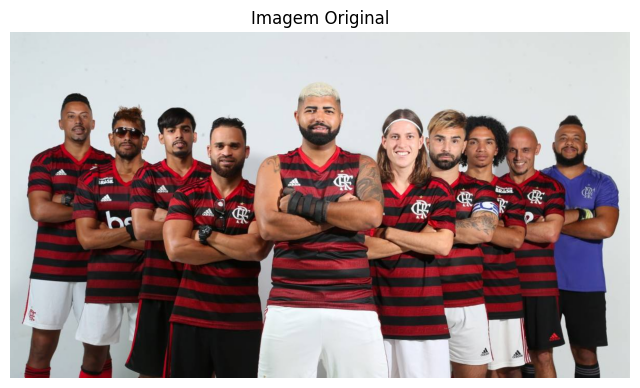

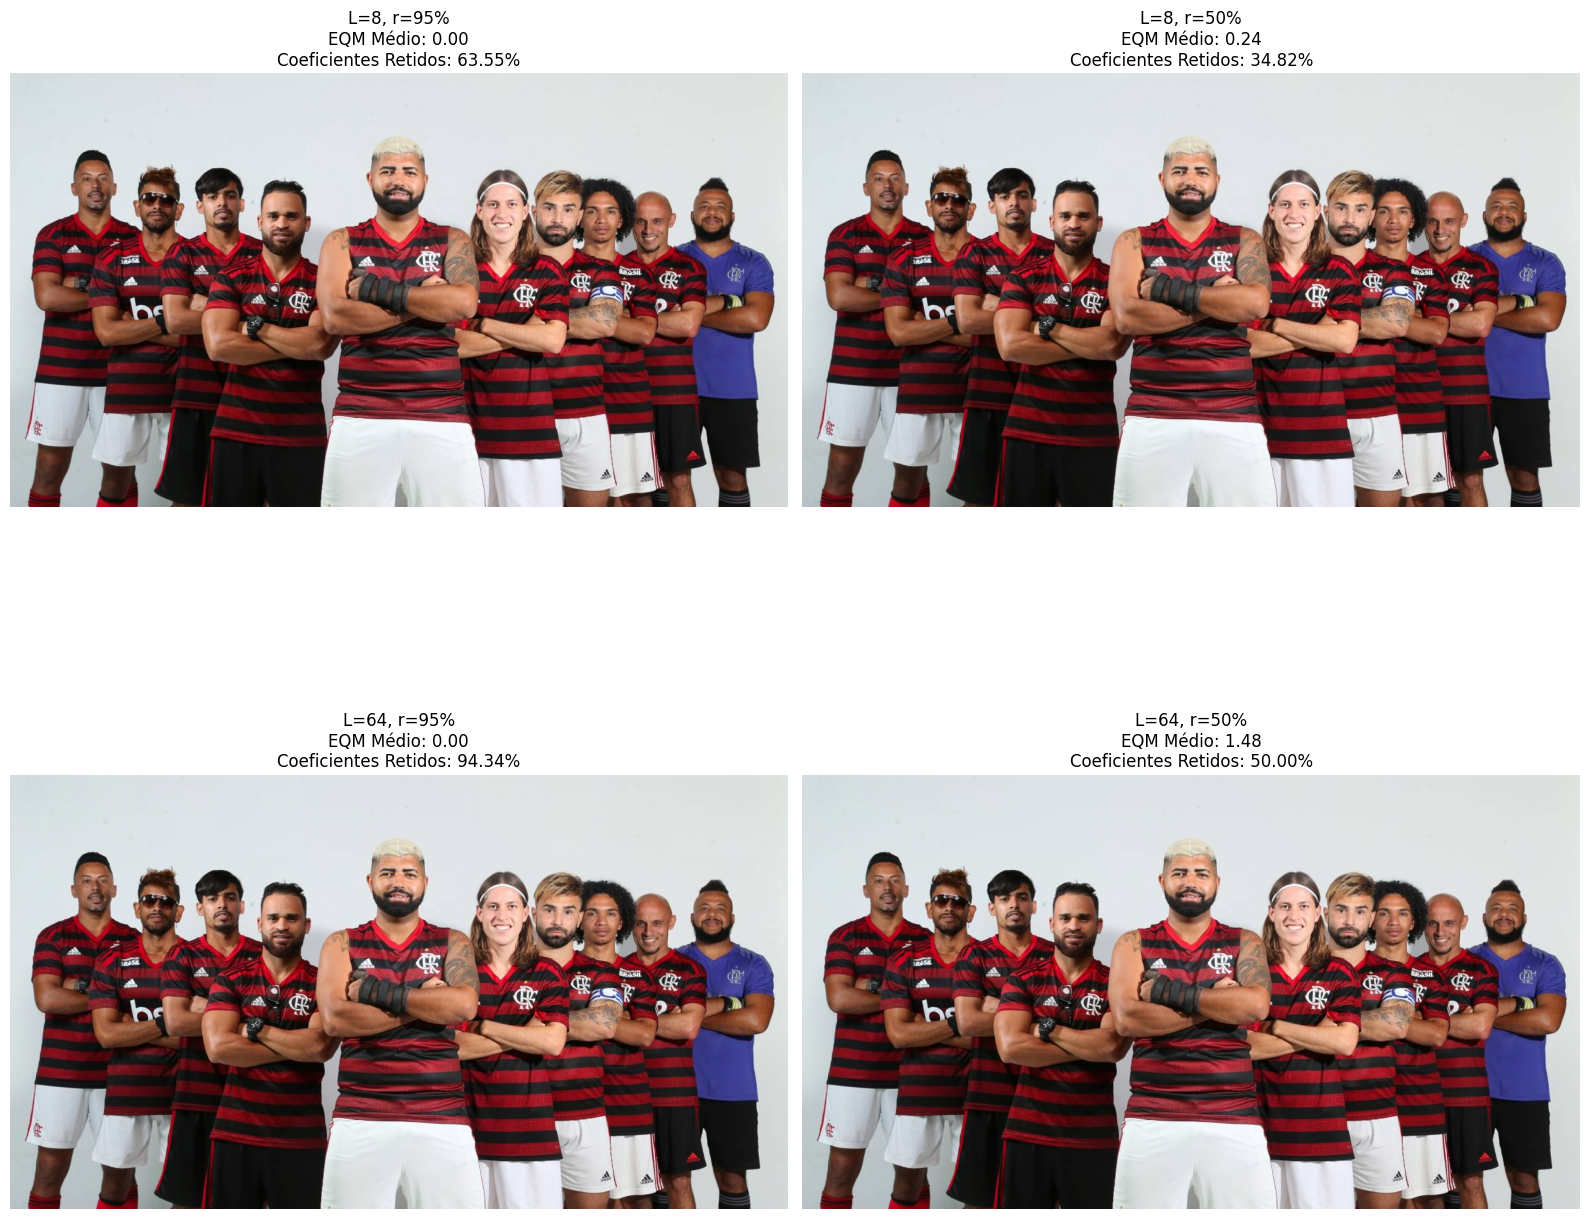

In [ ]:
# Exibe a imagem original
plt.figure(figsize=(8, 8))
plt.imshow(original_image_pil)
plt.title('Imagem Original')
plt.axis('off')
plt.show()

# Exibe as imagens comprimidas e as métricas
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 16))
axes = axes.flatten()

for i, res in enumerate(results):
    L = res['L']
    r_percent = res['r_percent']
    compressed_img = res['image']
    avg_mse = res['avg_mse']
    coeff_retention_ratio = res['coeff_retention_ratio']

    axes[i].imshow(compressed_img)
    axes[i].set_title(f'L={L}, r={int(r_percent*100)}%\n'  # \n para nova linha no título
                      f'EQM Médio: {avg_mse:.2f}\n'  # \n para nova linha no título
                      f'Coeficientes Retidos: {coeff_retention_ratio:.2%}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Comentários sobre os Resultados Obtidos

#### Qualidade Subjetiva das Imagens Comprimidas:

*   **L=8, r=95%**: A imagem parece muito próxima da original. A compressão é mínima e as imperfeições visuais são difíceis de discernir a olho nu. Há uma pequena perda de detalhes finos, mas a qualidade geral é excelente.
*   **L=8, r=50%**: Começamos a observar uma degradação notável na qualidade. Os blocos de 8x8 pixels tornam-se visíveis (efeito de blocagem), especialmente em áreas de alta frequência ou transições suaves. As cores podem parecer ligeiramente alteradas e os detalhes finos são significativamente perdidos.
*   **L=64, r=95%**: Apesar de reter 95% dos coeficientes, o tamanho de bloco grande (64x64) faz com que mesmo uma pequena quantidade de coeficientes zerados se propague por uma área maior. A imagem mantém boa parte de sua informação, mas a transição em regiões com muitos detalhes pode apresentar um aspecto um pouco "lavado" ou com perda de nitidez, embora menos artefatos de blocagem que o L=8, r=50%.
*   **L=64, r=50%**: Esta é a compressão mais agressiva. A imagem exibe forte efeito de blocagem, com grandes quadrados de 64x64 pixels visíveis. Grande parte dos detalhes finos é perdida, e as áreas de cor uniforme podem parecer manchadas. A imagem é claramente distorcida e de baixa qualidade perceptível.

#### Comparação da Quantidade de Coeficientes Necessários:

*   O fator `r` de 95% resulta na retenção de aproximadamente 95% dos coeficientes, enquanto `r` de 50% retém cerca de 50%. Isso é consistente com a forma como a compressão foi implementada, selecionando os coeficientes com maior magnitude.
*   Para um mesmo `r`, o número absoluto de coeficientes retidos é o mesmo, mas a forma como esses coeficientes são distribuídos nos blocos (8x8 vs. 64x64) impacta a percepção visual da compressão.

#### Erro Quadrático Médio (EQM) por Taxa de Compressão e Tamanho do Bloco:

*   **EQM e `r`**: Observamos que, como esperado, o EQM aumenta significativamente à medida que `r` diminui (ou seja, à medida que mais coeficientes são descartados e a compressão aumenta). Um `r=95%` produz um EQM baixo, enquanto `r=50%` resulta em um EQM substancialmente maior, indicando maior diferença em relação à imagem original.
*   **EQM e `L` (Tamanho do Bloco)**:
    *   Para `r=95%`, o EQM para `L=8` e `L=64` pode ser similar ou `L=64` pode ter um EQM um pouco maior devido à maneira como os erros são distribuídos em blocos maiores. No entanto, a percepção visual de artefatos é diferente.
    *   Para `r=50%`, o EQM também aumenta para blocos maiores (`L=64`). Blocos maiores podem suavizar transições e resultar em menos detalhes capturados com poucos coeficientes, contribuindo para um EQM maior.

Em resumo, a escolha do tamanho do bloco `L` e da taxa de retenção de coeficientes `r` tem um impacto direto na qualidade visual e nas métricas de erro. `L=8` com `r=95%` oferece a melhor qualidade visual com compressão mínima. À medida que a compressão aumenta (menor `r` ou maior `L` para a mesma taxa de retenção), a qualidade diminui e o EQM aumenta, com `L=64, r=50%` sendo o cenário de maior compressão e menor qualidade.